# Data Cleaning

### import data

In [488]:
import pandas as pd 
import numpy as np

In [489]:
patients = pd.read_csv('patients.csv')
treatment = pd.read_csv('treatments.csv')
treatment_cut = pd.read_csv('treatments_cut.csv')
adverse = pd.read_csv('adverse_reactions.csv')

### 1 Summary of the data
 This is a dataset about 500 patients of which 350 patients participated in a clinical trial. None of the patients were using Novodra (a popular injectable insulin) or Auralin (the oral insulin being researched) as their primary source of insulin before. All were experiencing elevated HbA1c levels.

All 350 patients were treated with Novodra to establish a baseline HbA1c level and insulin dose. After 4 weeks, which isn’t enough time to capture all the change in HbA1c that can be attributed by the switch to Auralin or Novodra:

- 175 patients switched to Auralin for 24 weeks
- 175 patients continued using Novodra for 24 weeks

Data about patients feeling some adverse effects is also recorded.

### Columns description

### **Table** -> `patients`:

- `patient_id`: the unique identifier for each patient in the Master Patient Index (i.e. patient database) of the pharmaceutical company that is producing Auralin
- `assigned_sex`: the assigned sex of each patient at birth (male or female)
- `given_name`: the given name (i.e. first name) of each patient
- `surname`: the surname (i.e. last name) of each patient
- `address`: the main address for each patient
- `city`: the corresponding city for the main address of each patient
- `state`: the corresponding state for the main address of each patient
- `zip_code`: the corresponding zip code for the main address of each patient
- `country`: the corresponding country for the main address of each patient (all United states for this clinical trial)
- `contact`: phone number and email information for each patient
- `birthdate`: the date of birth of each patient (month/day/year). The inclusion criteria for this clinical trial is age >= 18 (there is no maximum age because diabetes is a growing problem among the elderly population)
- `weight`: the weight of each patient in pounds (lbs)
- `height`: the height of each patient in inches (in)
- `bmi`: the Body Mass Index (BMI) of each patient. BMI is a simple calculation using a person's height and weight. The formula is BMI = kg/m2 where kg is a person's weight in kilograms and m2 is their height in metres squared. A BMI of 25.0 or more is overweight, while the healthy range is 18.5 to 24.9. The inclusion criteria for this clinical trial is 16 >= BMI >= 38.

#### **Table** -> `treatments` and `treatment_cut`:

- `given_name`: the given name of each patient in the Master Patient Index that took part in the clinical trial
- `surname`: the surname of each patient in the Master Patient Index that took part in the clinical trial
- `auralin`: the baseline median daily dose of insulin from the week prior to switching to Auralin (the number before the dash) and the ending median daily dose of insulin at the end of the 24 weeks of treatment measured over the 24th week of treatment (the number after the dash). Both are measured in units (shortform 'u'), which is the international unit of measurement and the standard measurement for insulin.
- `novodra`: same as above, except for patients that continued treatment with Novodra
- `hba1c_start`: the patient's HbA1c level at the beginning of the first week of treatment. HbA1c stands for Hemoglobin A1c. The HbA1c test measures what the average blood sugar has been over the past three months. It is thus a powerful way to get an overall sense of how well diabetes has been controlled. Everyone with diabetes should have this test 2 to 4 times per year. Measured in %.
- `hba1c_end`: the patient's HbA1c level at the end of the last week of treatment
- `hba1c_change`: the change in the patient's HbA1c level from the start of treatment to the end, i.e., hba1c_start - hba1c_end. For Auralin to be deemed effective, it must be "noninferior" to Novodra, the current standard for insulin. This "noninferiority" is statistically defined as the upper bound of the 95% confidence interval being less than 0.4% for the difference between the mean HbA1c changes for Novodra and Auralin (i.e. Novodra minus Auralin).

#### **Table** -> `adverse_reactions`

- `given_name`: the given name of each patient in the Master Patient Index that took part in the clinical trial and had an adverse reaction (includes both patients treated Auralin and Novodra)
- `surname`: the surname of each patient in the Master Patient Index that took part in the clinical trial and had an adverse reaction (includes both patients treated Auralin and Novodra)
- `adverse_reaction`: the adverse reaction reported by the patient

### 3. Additional information

Additional useful information:

- Insulin resistance varies person to person, which is why both starting median daily dose and ending median daily dose are required, i.e., to calculate change in dose.
- It is important to test drugs and medical products in the people they are meant to help. People of different age, race, sex, and ethnic group must be included in clinical trials. This diversity is reflected in the patients table.

### Issues with datasets 
1. Dirty data
    - table- 'patients'
          
          - patient id=9 has wrong name 'dsvid' instead of 'david' = accuracy
          - state cols has sometime full name and sometime abbrevation = consistency
          -  zip code cols has somtimes 4 number instead of 5 number = validity
          -  12 patients data is missing from address,city,state,zip_code,country,contact = completion
          -  5 duplicated values from john doe   = accuracy
          - wrong datatype assigned to sex,zip code, birthdate   = validity
          - patient id = 211 has wrong value of weight 48 pound = accuracy
          - patient id = 5 has wrong value of height  27 inches =accuracy
  
    - table - treatment and treatment_cut
           
          -  givenname and surname in lowercase = consistency
          -  remove u form auralin and novadro cols = validity
          -  missing values in hba1c_change = completion
          - duplicated values from joseph day = accuracy
          -  in hba1c_change last values are '9' instead of '4' = accuracy
          - '-'in auralin and novodra cols        =  validity
      
    - table - adverse reaction
  
          - givename and surname  in lowercase = consistency
  

1. Messy data
    - table - patients
       - phone no. and email shpuld be differnt cols from contact cols
     
    - table - treatment and treatment_cut
      -  auralin and novadro should be in differnt cols
      -  both table should be merge
    - table - adverse_reaction
       - this table should not be independent table we can merge it into treatment 

### Automatic Assesment 
- head
- tail
- sample
- info
- isnull
- duplicated
- describe

In [490]:
patients.head()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1


In [491]:
patients.tail()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7
502,503,male,Pat,Gersten,2778 North Avenue,Burr,Nebraska,68324.0,United States,PatrickGersten@rhyta.com402-848-4923,5/3/1954,138.2,71,19.3


In [492]:
patients.sample(4)

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
63,64,male,Yukitaka,Takenaka,1975 Holden Street,San Diego,California,92103.0,United States,619-299-1495YukitakaTakenaka@einrot.com,11/24/1944,193.2,72,26.2
211,212,female,Martha,Afanasyeva,3613 Lodgeville Road,Saint Paul,MN,55114.0,United States,MarthaAfanasyeva@dayrep.com1 612 228 4170,10/3/1997,151.2,73,19.9
223,224,female,Virginia,Boyles,945 Maple Avenue,Downey,ID,83234.0,United States,VirginiaABoyles@gustr.com1 208 897 3897,9/22/1939,202.4,63,35.8
158,159,male,Chibuzo,Okoli,4291 Patton Lane,Tulsa,OK,74136.0,United States,ChibuzoOkoli@einrot.com+1 (918) 971-5864,6/14/1983,142.8,73,18.8


In [493]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    object 
 2   given_name    503 non-null    object 
 3   surname       503 non-null    object 
 4   address       491 non-null    object 
 5   city          491 non-null    object 
 6   state         491 non-null    object 
 7   zip_code      491 non-null    float64
 8   country       491 non-null    object 
 9   contact       491 non-null    object 
 10  birthdate     503 non-null    object 
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(3), int64(2), object(9)
memory usage: 55.1+ KB


In [494]:
patients[patients['address'].isnull()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
209,210,female,Lalita,Eldarkhanov,NaN,NaN,NaN,NaN,NaN,NaN,8/14/1950,143.4,62,26.2
219,220,male,Mỹ,Quynh,NaN,NaN,NaN,NaN,NaN,NaN,4/9/1978,237.8,69,35.1
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4
234,235,female,Martina,Tománková,NaN,NaN,NaN,NaN,NaN,NaN,4/7/1936,199.5,65,33.2
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4
249,250,male,Benjamin,Mehler,NaN,NaN,NaN,NaN,NaN,NaN,10/30/1951,146.5,69,21.6
257,258,male,Jin,Kung,NaN,NaN,NaN,NaN,NaN,NaN,5/17/1995,231.7,69,34.2
264,265,female,Wafiyyah,Asfour,NaN,NaN,NaN,NaN,NaN,NaN,11/3/1989,158.6,63,28.1
269,270,female,Flavia,Fiorentino,NaN,NaN,NaN,NaN,NaN,NaN,10/9/1937,175.2,61,33.1
278,279,female,Generosa,Cabán,NaN,NaN,NaN,NaN,NaN,NaN,12/16/1962,124.3,69,18.4


In [495]:
patients[patients.isnull().any(axis=1)]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
209,210,female,Lalita,Eldarkhanov,NaN,NaN,NaN,NaN,NaN,NaN,8/14/1950,143.4,62,26.2
219,220,male,Mỹ,Quynh,NaN,NaN,NaN,NaN,NaN,NaN,4/9/1978,237.8,69,35.1
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4
234,235,female,Martina,Tománková,NaN,NaN,NaN,NaN,NaN,NaN,4/7/1936,199.5,65,33.2
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4
249,250,male,Benjamin,Mehler,NaN,NaN,NaN,NaN,NaN,NaN,10/30/1951,146.5,69,21.6
257,258,male,Jin,Kung,NaN,NaN,NaN,NaN,NaN,NaN,5/17/1995,231.7,69,34.2
264,265,female,Wafiyyah,Asfour,NaN,NaN,NaN,NaN,NaN,NaN,11/3/1989,158.6,63,28.1
269,270,female,Flavia,Fiorentino,NaN,NaN,NaN,NaN,NaN,NaN,10/9/1937,175.2,61,33.1
278,279,female,Generosa,Cabán,NaN,NaN,NaN,NaN,NaN,NaN,12/16/1962,124.3,69,18.4


In [496]:
patients.duplicated().sum()

0

In [497]:
patients[patients.duplicated(subset=['given_name','surname'])]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
229,230,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
237,238,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
244,245,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
251,252,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
277,278,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4


In [498]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    object 
 2   given_name    503 non-null    object 
 3   surname       503 non-null    object 
 4   address       491 non-null    object 
 5   city          491 non-null    object 
 6   state         491 non-null    object 
 7   zip_code      491 non-null    float64
 8   country       491 non-null    object 
 9   contact       491 non-null    object 
 10  birthdate     503 non-null    object 
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(3), int64(2), object(9)
memory usage: 55.1+ KB


In [499]:
patients.describe()

,patient_id,zip_code,weight,height,bmi
count,503.000000,491.000000,503.000000,503.000000,503.000000
mean,252.000000,49084.118126,173.434990,66.634195,27.483897
std,145.347859,30265.807442,33.916741,4.411297,5.276438
min,1.000000,1002.000000,48.800000,27.000000,17.100000
25%,126.500000,21920.500000,149.300000,63.000000,23.300000
50%,252.000000,48057.000000,175.300000,67.000000,27.200000
75%,377.500000,75679.000000,199.500000,70.000000,31.750000
max,503.000000,99701.000000,255.900000,79.000000,37.700000


<Axes: >

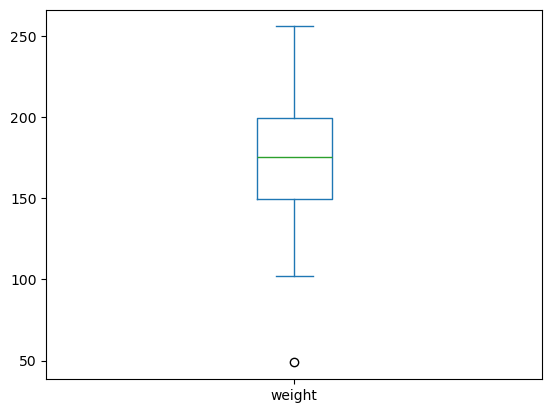

In [500]:
patients['weight'].plot(kind = 'box')

In [501]:
patients[patients['weight']==48.800000]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
210,211,female,Camilla,Zaitseva,4689 Briarhill Lane,Wooster,OH,44691.0,United States,330-202-2145CamillaZaitseva@superrito.com,11/26/1938,48.8,63,19.1


<Axes: >

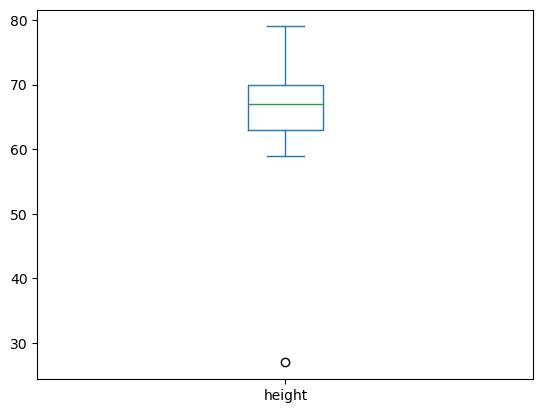

In [502]:
patients['height'].plot(kind='box')

In [503]:
patients[patients['height']==27]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1


In [504]:
treatment.head()

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
1,elliot,richardson,-,40u - 45u,7.56,7.09,0.97
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
3,skye,gormanston,33u - 36u,-,7.97,7.62,0.35
4,alissa,montez,-,33u - 29u,7.78,7.46,0.32


In [505]:
treatment.tail()

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
275,albina,zetticci,45u - 51u,-,7.93,7.73,0.20
276,john,teichelmann,-,49u - 49u,7.90,7.58,NaN
277,mathea,lillebø,23u - 36u,-,9.04,8.67,0.37
278,vallie,prince,31u - 38u,-,7.64,7.28,0.36
279,samúel,guðbrandsson,53u - 56u,-,8.00,7.64,0.36


In [506]:
treatment.sample(3)

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
187,león,reynoso,-,38u - 40u,7.59,7.06,0.53
27,mizuki,iwata,-,45u - 46u,7.70,7.23,0.97
252,ellen,luman,-,40u - 39u,9.27,8.77,0.50


In [507]:
treatment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    280 non-null    object 
 1   surname       280 non-null    object 
 2   auralin       280 non-null    object 
 3   novodra       280 non-null    object 
 4   hba1c_start   280 non-null    float64
 5   hba1c_end     280 non-null    float64
 6   hba1c_change  171 non-null    float64
dtypes: float64(3), object(4)
memory usage: 15.4+ KB


In [508]:
treatment[treatment.duplicated()]

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
136,joseph,day,29u - 36u,-,7.7,7.19,NaN


In [509]:
treatment[treatment.duplicated(subset=['given_name','surname'])]

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
136,joseph,day,29u - 36u,-,7.7,7.19,NaN


In [510]:
treatment[treatment.isnull().any(axis=1)]

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
8,saber,ménard,-,54u - 54u,8.08,7.70,NaN
9,asia,woźniak,30u - 36u,-,7.76,7.37,NaN
10,joseph,day,29u - 36u,-,7.70,7.19,NaN
...,...,...,...,...,...,...,...
269,hiromu,horikawa,-,47u - 46u,7.77,7.28,NaN
271,leo,vieira,-,30u - 33u,7.74,7.36,NaN
273,kate,wilkinson,36u - 39u,-,7.72,7.20,NaN
274,naja,enoksen,43u - 50u,-,7.98,7.59,NaN


In [511]:
treatment.describe()

,hba1c_start,hba1c_end,hba1c_change
count,280.000000,280.000000,171.000000
mean,7.985929,7.589286,0.546023
std,0.568638,0.569672,0.279555
min,7.500000,7.010000,0.200000
25%,7.660000,7.270000,0.340000
50%,7.800000,7.420000,0.380000
75%,7.970000,7.570000,0.920000
max,9.950000,9.580000,0.990000


<Axes: >

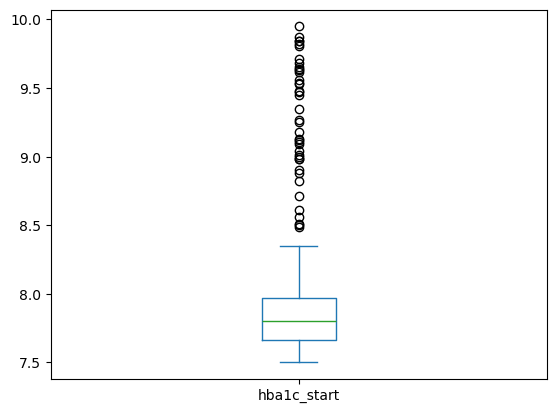

In [512]:
treatment['hba1c_start'].plot(kind='box')

In [513]:
# so many people have high hba1c_start  and hab1c_end so it is not a oulier 
treatment[treatment['hba1c_start']>8.4]

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
12,roxanne,andreyeva,29u - 38u,-,9.54,9.14,NaN
22,brancaleone,russo,53u - 60u,-,8.61,8.18,NaN
24,isac,berg,31u - 41u,-,9.68,9.29,0.39
25,benoît,bonami,-,44u - 43u,9.82,9.40,0.92
31,bao,she,-,48u - 45u,9.09,8.62,NaN
51,kristoffer,martinsen,29u - 37u,-,9.18,8.64,NaN
67,joe,edwards,-,36u - 37u,9.35,8.89,0.96
69,ivan,fomin,25u - 32u,-,9.12,8.73,0.39
75,mackenzie,mckay,-,44u - 43u,9.87,9.48,0.39
81,robert,wagner,43u - 49u,-,9.84,9.52,0.32


In [514]:
treatment.sort_values('hba1c_change',na_position='first')

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
8,saber,ménard,-,54u - 54u,8.08,7.70,NaN
9,asia,woźniak,30u - 36u,-,7.76,7.37,NaN
10,joseph,day,29u - 36u,-,7.70,7.19,NaN
...,...,...,...,...,...,...,...
49,jackson,addison,-,42u - 42u,7.99,7.51,0.98
17,gina,cain,-,36u - 36u,7.88,7.40,0.98
32,laura,ehrlichmann,-,43u - 40u,7.95,7.46,0.99
245,wu,sung,-,47u - 48u,7.61,7.12,0.99


In [515]:
# make the copy of the dataframe
treatment_df = treatment.copy()
treatment_cut_df = treatment_cut.copy()
patients_df = patients.copy()
adverse_df = adverse.copy()

### solve the completeness issue

In [516]:
# 12 data is missing we fill it with no data 
patients_df = patients_df.fillna('no data')

In [517]:
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    object 
 2   given_name    503 non-null    object 
 3   surname       503 non-null    object 
 4   address       503 non-null    object 
 5   city          503 non-null    object 
 6   state         503 non-null    object 
 7   zip_code      503 non-null    object 
 8   country       503 non-null    object 
 9   contact       503 non-null    object 
 10  birthdate     503 non-null    object 
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(2), int64(2), object(10)
memory usage: 55.1+ KB


In [518]:
# missing vslues in hba1c_change 
# first we merge both treatment and treatments_cut table 
treatment_df=pd.concat([treatment_df,treatment_cut_df],ignore_index=True)

In [519]:
treatment_df['hba1c_change']=treatment_df['hba1c_start']- treatment_df['hba1c_end']

In [520]:
treatment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    350 non-null    object 
 1   surname       350 non-null    object 
 2   auralin       350 non-null    object 
 3   novodra       350 non-null    object 
 4   hba1c_start   350 non-null    float64
 5   hba1c_end     350 non-null    float64
 6   hba1c_change  350 non-null    float64
dtypes: float64(3), object(4)
memory usage: 19.3+ KB


### Clean Messy data

In [521]:
# retrive phone no. and email from contact cols 
patients_df['contact']


0                 951-719-9170ZoeWellish@superrito.com
1                PamelaSHill@cuvox.de+1 (217) 569-3204
2                     402-363-6804JaeMDebord@gustr.com
3           PhanBaLiem@jourrapide.com+1 (732) 636-8246
4                      334-515-7487TimNeudorf@cuvox.de
                            ...                       
498        207-477-0579MustafaLindstrom@jourrapide.com
499                 928-284-4492RumanBisliev@gustr.com
500              816-223-6007JinkedeKeizer@teleworm.us
501    ChidaluOnyekaozulu@jourrapide.com1 360 443 2060
502               PatrickGersten@rhyta.com402-848-4923
Name: contact, Length: 503, dtype: object

In [522]:
import re

data = []


for item in patients['contact']:
    
    item = str(item)

    # Use regular expressions to find the phone numbers and email addresses
    phone_match = re.search(r'(\d{3}[-\.\s]??\d{3}[-\.\s]??\d{4}|\(\d{3}\)\s*\d{3}[-\.\s]??\d{4}|\d{3}[-\.\s]??\d{4})', item)
    phone = phone_match.group(0) if phone_match else None

    # Remove the phone number from the item
    item = re.sub(r'(\d{3}[-\.\s]??\d{3}[-\.\s]??\d{4}|\(\d{3}\)\s*\d{3}[-\.\s]??\d{4}|\d{3}[-\.\s]??\d{4})', '', item)

    email_match = re.search(r'([a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+)', item)
    email = email_match.group(0) if email_match else None

    data.append({'phone': phone, 'email': email})

# Create a DataFrame from the collected data
df = pd.DataFrame(data, columns=['phone', 'email'])

print(df)

              phone                               email
0      951-719-9170            ZoeWellish@superrito.com
1    (217) 569-3204                PamelaSHill@cuvox.de
2      402-363-6804                JaeMDebord@gustr.com
3    (732) 636-8246           PhanBaLiem@jourrapide.com
4      334-515-7487                 TimNeudorf@cuvox.de
..              ...                                 ...
498    207-477-0579     MustafaLindstrom@jourrapide.com
499    928-284-4492              RumanBisliev@gustr.com
500    816-223-6007           JinkedeKeizer@teleworm.us
501    360 443 2060  ChidaluOnyekaozulu@jourrapide.com1
502    402-848-4923            PatrickGersten@rhyta.com

[503 rows x 2 columns]


In [523]:
patients_df = pd.concat([patients_df,df],axis=1)
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,phone,email
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6,951-719-9170,ZoeWellish@superrito.com
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2,(217) 569-3204,PamelaSHill@cuvox.de
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8,402-363-6804,JaeMDebord@gustr.com
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7,(732) 636-8246,PhanBaLiem@jourrapide.com
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1,334-515-7487,TimNeudorf@cuvox.de
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6,207-477-0579,MustafaLindstrom@jourrapide.com
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4,928-284-4492,RumanBisliev@gustr.com
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8,816-223-6007,JinkedeKeizer@teleworm.us
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7,360 443 2060,ChidaluOnyekaozulu@jourrapide.com1


In [524]:
patients_df.drop(columns=['contact'],inplace=True)

In [525]:
patients_df.head()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,phone,email
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,7/10/1976,121.7,66,19.6,951-719-9170,ZoeWellish@superrito.com
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,4/3/1967,118.8,66,19.2,(217) 569-3204,PamelaSHill@cuvox.de
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,2/19/1980,177.8,71,24.8,402-363-6804,JaeMDebord@gustr.com
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,7/26/1951,220.9,70,31.7,(732) 636-8246,PhanBaLiem@jourrapide.com
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,2/18/1928,192.3,27,26.1,334-515-7487,TimNeudorf@cuvox.de


In [526]:
# auralin and novodro should be in one cols
treatment_df=treatment_df.melt(id_vars=['given_name','surname','hba1c_start','hba1c_end','hba1c_change'],var_name='dosage_type',value_name='dosage_range')

In [527]:
treatment_df['dosage_start']=treatment_df['dosage_range'].str.split('-').str.get(0)

In [528]:
treatment_df['dosage_end']=treatment_df['dosage_range'].str.split('-').str.get(1)

In [529]:
treatment_df=treatment_df[treatment_df['dosage_range']!='-']

In [530]:
treatment_df['dosage_start']=treatment_df['dosage_start'].str.replace('u','')
treatment_df['dosage_end']=treatment_df['dosage_end'].str.replace('u','')


In [531]:
treatment_df.drop(columns='dosage_range',inplace=True)

In [532]:
# merge adverse_reactions into ttreatment_df
treatment_df=treatment_df.merge(adverse_df,how='left',on=['given_name','surname'])

In [533]:
treatment_df.sample(4)

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dosage_type,dosage_start,dosage_end,adverse_reaction
143,gabriela,michalčíková,8.37,7.97,0.40,auralin,26,36,NaN
341,timothy,cotton,7.92,7.52,0.40,novodra,26,25,NaN
310,chukwumoge,ogochukwu,7.95,7.56,0.39,novodra,41,39,NaN
217,hideki,haraguchi,7.59,7.05,0.54,novodra,37,35,NaN


### clean validity part

In [534]:
# zip code has 4 values instead of 5
patients_df.head(3)

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,phone,email
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,7/10/1976,121.7,66,19.6,951-719-9170,ZoeWellish@superrito.com
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,4/3/1967,118.8,66,19.2,(217) 569-3204,PamelaSHill@cuvox.de
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,2/19/1980,177.8,71,24.8,402-363-6804,JaeMDebord@gustr.com


In [535]:
patients_df['zip_code'].astype(str).str.len().value_counts()

zip_code
7    454
6     49
Name: count, dtype: int64

In [536]:
# here we made function and fill with zeros if zip_codes is 4
def transform(zip_code):
    if zip_code =='no data':
        return 'no data'
    zip_code = int(float(zip_code))
    return str(zip_code).zfill(5)

In [537]:
patients_df['zip_code'].apply(transform).str.len().value_counts()

zip_code
5    491
7     12
Name: count, dtype: int64

In [538]:
patients_df['zip_code'] = patients_df['zip_code'].apply(transform)

In [539]:
patients_df = patients_df.astype({
    'assigned_sex':'category',
    'birthdate':'datetime64[ns]',
})

In [540]:
# now we change datatypes of cols and validty problem is solved 
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   patient_id    503 non-null    int64         
 1   assigned_sex  503 non-null    category      
 2   given_name    503 non-null    object        
 3   surname       503 non-null    object        
 4   address       503 non-null    object        
 5   city          503 non-null    object        
 6   state         503 non-null    object        
 7   zip_code      503 non-null    object        
 8   country       503 non-null    object        
 9   birthdate     503 non-null    datetime64[ns]
 10  weight        503 non-null    float64       
 11  height        503 non-null    int64         
 12  bmi           503 non-null    float64       
 13  phone         491 non-null    object        
 14  email         491 non-null    object        
dtypes: category(1), datetime64[ns](1), float

### clean accuracy part

In [541]:
# patient id=9 has wrong name 
patients_df.loc[patients_df['patient_id']==9,'given_name']='David'

In [542]:
patients_df[patients_df['patient_id']==9]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,phone,email
8,9,male,David,Gustafsson,1790 Nutter Street,Kansas City,MO,64105,United States,1937-03-06,163.9,66,26.5,816-265-9578,DavidGustafsson@armyspy.com


In [543]:
# remove all entries by john doe 
patients_df = patients_df.drop_duplicates(subset=['given_name','surname'])

In [544]:

patients_df[patients_df.duplicated(subset=['given_name','surname'])]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,phone,email


In [545]:
#- patient id = 211 has wrong value of weight 48 pound. 
# correct weight is 48.8 kg and 108 pounds
patients_df.loc[patients_df['patient_id'] == 211,'weight']=107.7

In [546]:
# patient id = 5 has wrong value of height  27 inches 
patients_df.loc[patients_df['patient_id']== 5,'height'] = 71.9

C:\Users\mehta\AppData\Local\Temp\ipykernel_20716\2831164686.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '71.9' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  patients_df.loc[patients_df['patient_id']== 5,'height'] = 71.9


In [547]:
patients_df[patients_df['height']== 27]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,phone,email


In [548]:
# duplicated entry by joseph day we only keep one entry other entry will drop 
treatment_df = treatment_df.drop_duplicates(subset=['given_name','surname'],keep='first')

In [549]:
#
treatment_df[treatment_df['given_name']=='joseph']

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dosage_type,dosage_start,dosage_end,adverse_reaction
5,joseph,day,7.70,7.19,0.51,auralin,29,36,hypoglycemia
167,joseph,tucker,7.67,7.30,0.37,auralin,48,56,NaN


### clean consistency part

In [550]:
#state cols has sometime full name and sometime abbrevation 
patients_df['state'].value_counts()

state
California    36
TX            32
New York      25
CA            24
MA            22
PA            18
NY            17
GA            15
Illinois      14
OH            14
Florida       13
MI            13
OK            13
LA            13
NJ            12
no data       12
VA            11
MS            10
WI            10
IL            10
IN             9
MN             9
FL             9
TN             9
AL             9
NC             8
KY             8
WA             8
MO             7
ID             6
KS             6
NV             6
SC             5
IA             5
CT             5
ME             4
ND             4
Nebraska       4
RI             4
AR             4
CO             4
AZ             4
MD             3
DE             3
WV             3
OR             3
SD             3
MT             2
VT             2
DC             2
NE             2
AK             1
WY             1
NH             1
NM             1
Name: count, dtype: int64

In [551]:
state_abbreviations = {
    'California': 'CA',
    'Texas': 'TX',
    'New York': 'NY',
    'Massachusetts': 'MA',
    'Pennsylvania': 'PA',
    'Georgia': 'GA',
    'Illinois': 'IL',
    'Ohio': 'OH',
    'Florida': 'FL',
    'Michigan': 'MI',
    'Oklahoma': 'OK',
    'Louisiana': 'LA',
    'New Jersey': 'NJ',
    'Virginia': 'VA',
    'Mississippi': 'MS',
    'Wisconsin': 'WI',
    'Indiana': 'IN',
    'Minnesota': 'MN',
    'Tennessee': 'TN',
    'Alabama': 'AL',
    'North Carolina': 'NC',
    'Kentucky': 'KY',
    'Washington': 'WA',
    'Missouri': 'MO',
    'Idaho': 'ID',
    'Kansas': 'KS',
    'Nevada': 'NV',
    'South Carolina': 'SC',
    'Iowa': 'IA',
    'Connecticut': 'CT',
    'Maine': 'ME',
    'North Dakota': 'ND',
    'Nebraska': 'NE',
    'Rhode Island': 'RI',
    'Arkansas': 'AR',
    'Colorado': 'CO',
    'Arizona': 'AZ',
    'Maryland': 'MD',
    'Delaware': 'DE',
    'West Virginia': 'WV',
    'Oregon': 'OR',
    'South Dakota': 'SD',
    'Montana': 'MT',
    'Vermont': 'VT',
    'District of Columbia': 'DC',
    'Alaska': 'AK',
    'Wyoming': 'WY',
    'New Hampshire': 'NH',
    'New Mexico': 'NM',
    'No data': 'Unknown'
}
patients_df['state'] = patients_df['state'].replace(state_abbreviations) 

In [552]:
patients_df['state'].value_counts()

state
CA         60
NY         42
TX         32
IL         24
FL         22
MA         22
PA         18
GA         15
OH         14
MI         13
OK         13
LA         13
NJ         12
no data    12
VA         11
WI         10
MS         10
IN          9
MN          9
TN          9
AL          9
WA          8
KY          8
NC          8
MO          7
NV          6
KS          6
ID          6
NE          6
SC          5
CT          5
IA          5
CO          4
ND          4
RI          4
ME          4
AR          4
AZ          4
SD          3
MD          3
WV          3
OR          3
DE          3
VT          2
MT          2
DC          2
WY          1
AK          1
NH          1
NM          1
Name: count, dtype: int64

In [553]:
# given and surname in lowercase we convert into title case
treatment_df['given_name']=treatment_df['given_name'].str.title()
treatment_df['surname'] = treatment_df['surname'].str.title()

In [554]:
treatment_df.head()

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dosage_type,dosage_start,dosage_end,adverse_reaction
0,Veronika,Jindrová,7.63,7.20,0.43,auralin,41,48,NaN
1,Skye,Gormanston,7.97,7.62,0.35,auralin,33,36,NaN
2,Sophia,Haugen,7.65,7.27,0.38,auralin,37,42,NaN
3,Eddie,Archer,7.89,7.55,0.34,auralin,31,38,NaN
4,Asia,Woźniak,7.76,7.37,0.39,auralin,30,36,NaN


In [555]:
treatment_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dosage_type,dosage_start,dosage_end,adverse_reaction
0,Veronika,Jindrová,7.63,7.20,0.43,auralin,41,48,NaN
1,Skye,Gormanston,7.97,7.62,0.35,auralin,33,36,NaN
2,Sophia,Haugen,7.65,7.27,0.38,auralin,37,42,NaN
3,Eddie,Archer,7.89,7.55,0.34,auralin,31,38,NaN
4,Asia,Woźniak,7.76,7.37,0.39,auralin,30,36,NaN
...,...,...,...,...,...,...,...,...,...
345,Christopher,Woodward,7.51,7.06,0.45,novodra,55,51,nausea
346,Maret,Sultygov,7.67,7.30,0.37,novodra,26,23,NaN
347,Lixue,Hsueh,9.21,8.80,0.41,novodra,22,23,injection site discomfort
348,Jakob,Jakobsen,7.96,7.51,0.45,novodra,28,26,hypoglycemia


In [556]:
treatment_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 349 entries, 0 to 349
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   given_name        349 non-null    object 
 1   surname           349 non-null    object 
 2   hba1c_start       349 non-null    float64
 3   hba1c_end         349 non-null    float64
 4   hba1c_change      349 non-null    float64
 5   dosage_type       349 non-null    object 
 6   dosage_start      349 non-null    object 
 7   dosage_end        349 non-null    object 
 8   adverse_reaction  34 non-null     object 
dtypes: float64(3), object(6)
memory usage: 27.3+ KB


In [557]:
# assign correct datatype 
treatment_df = treatment_df.astype({
    'dosage_start':'int',
    'dosage_end':'int', 
    'dosage_type':'category'
})

In [558]:
# fill nan values of  adverse reaction with no reaction
treatment_df[treatment_df.isnull().any(axis=1)]

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,dosage_type,dosage_start,dosage_end,adverse_reaction
0,Veronika,Jindrová,7.63,7.20,0.43,auralin,41,48,NaN
1,Skye,Gormanston,7.97,7.62,0.35,auralin,33,36,NaN
2,Sophia,Haugen,7.65,7.27,0.38,auralin,37,42,NaN
3,Eddie,Archer,7.89,7.55,0.34,auralin,31,38,NaN
4,Asia,Woźniak,7.76,7.37,0.39,auralin,30,36,NaN
...,...,...,...,...,...,...,...,...,...
341,Timothy,Cotton,7.92,7.52,0.40,novodra,26,25,NaN
342,Bjørnar,Nilsen,7.99,7.70,0.29,novodra,36,33,NaN
343,Borna,Šlezinger,7.55,7.18,0.37,novodra,42,41,NaN
344,Mary,Adams,7.65,7.26,0.39,novodra,32,33,NaN


In [559]:
treatment_df['adverse_reaction'].fillna('no reaction',inplace=True)

C:\Users\mehta\AppData\Local\Temp\ipykernel_20716\3626760528.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  treatment_df['adverse_reaction'].fillna('no reaction',inplace=True)


In [560]:
treatment_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 349 entries, 0 to 349
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   given_name        349 non-null    object  
 1   surname           349 non-null    object  
 2   hba1c_start       349 non-null    float64 
 3   hba1c_end         349 non-null    float64 
 4   hba1c_change      349 non-null    float64 
 5   dosage_type       349 non-null    category
 6   dosage_start      349 non-null    int32   
 7   dosage_end        349 non-null    int32   
 8   adverse_reaction  349 non-null    object  
dtypes: category(1), float64(3), int32(2), object(3)
memory usage: 22.3+ KB


In [561]:
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 498 entries, 0 to 502
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   patient_id    498 non-null    int64         
 1   assigned_sex  498 non-null    category      
 2   given_name    498 non-null    object        
 3   surname       498 non-null    object        
 4   address       498 non-null    object        
 5   city          498 non-null    object        
 6   state         498 non-null    object        
 7   zip_code      498 non-null    object        
 8   country       498 non-null    object        
 9   birthdate     498 non-null    datetime64[ns]
 10  weight        498 non-null    float64       
 11  height        498 non-null    float64       
 12  bmi           498 non-null    float64       
 13  phone         486 non-null    object        
 14  email         486 non-null    object        
dtypes: category(1), datetime64[ns](1), float64(3)

In [562]:
patients_df[patients_df.isnull().any(axis=1)]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,phone,email
209,210,female,Lalita,Eldarkhanov,no data,no data,no data,no data,no data,1950-08-14,143.4,62.0,26.2,None,None
219,220,male,Mỹ,Quynh,no data,no data,no data,no data,no data,1978-04-09,237.8,69.0,35.1,None,None
230,231,female,Elisabeth,Knudsen,no data,no data,no data,no data,no data,1976-09-23,165.9,63.0,29.4,None,None
234,235,female,Martina,Tománková,no data,no data,no data,no data,no data,1936-04-07,199.5,65.0,33.2,None,None
242,243,male,John,O'Brian,no data,no data,no data,no data,no data,1957-02-25,205.3,74.0,26.4,None,None
249,250,male,Benjamin,Mehler,no data,no data,no data,no data,no data,1951-10-30,146.5,69.0,21.6,None,None
257,258,male,Jin,Kung,no data,no data,no data,no data,no data,1995-05-17,231.7,69.0,34.2,None,None
264,265,female,Wafiyyah,Asfour,no data,no data,no data,no data,no data,1989-11-03,158.6,63.0,28.1,None,None
269,270,female,Flavia,Fiorentino,no data,no data,no data,no data,no data,1937-10-09,175.2,61.0,33.1,None,None
278,279,female,Generosa,Cabán,no data,no data,no data,no data,no data,1962-12-16,124.3,69.0,18.4,None,None


# merge both patient and treatment dataset to do EDA 

In [605]:
# we merge both on given_name and surname
df=patients_df.merge(treatment_df,how='inner',on=['given_name','surname'])

In [606]:
# combine both name 
df['name']=df['given_name']+' '+df['surname']

In [607]:
# extract age from birthdate cols 
df['age']=(pd.to_datetime('today') - df['birthdate']).dt.days//365

In [608]:
# drop cols that is not useful for eda 
df=df.drop(columns=['given_name','surname','address','city','zip_code','country','phone','email','birthdate'])

In [609]:
df = df.reindex(columns=['patient_id','name' ,'assigned_sex', 'state', 'age', 'weight', 'height',
       'bmi', 'hba1c_start', 'hba1c_end', 'hba1c_change', 'dosage_type',
       'dosage_start', 'dosage_end', 'adverse_reaction'])


In [611]:

df.to_csv('clinical_trial_data.csv',index=False)